<a href="https://colab.research.google.com/github/sidchaini/Death-and-Taxes/blob/main/willow-and-sid/20260226_DeathAndTaxes_Prototype_Latent_Space_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authors: Willow and Sid
Date: 2026-02-26

Rough description of this notebook:
For now, working with Willow's clean dataset of spectra from ABC-SN. And because they're on a grid, we can only consider the same no. of patches. This exact approach won't work for WISERep, but exploring methodology for now.

Using a simple autoencoder with 3 latent space points, and visualizing them to find correlations with physics.

Plotting using plotly for interactive plot, colouring by class (`maintype.html`) for all SN and by phase (`spectralphase.html`) for Ia-norm only. `spectralphase.html` shows an interesting pattern!

In [1]:
seed_val = 1709

import numpy as np
np.random.seed(seed_val)
import keras
keras.utils.set_random_seed(seed_val)

In [2]:
%%capture
import sys

!git clone https://github.com/FoxFortino/ABC-SN.git
sys.path.insert(0, "ABC-SN/code")
import data_preparation as dp

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import numba
from keras.utils import pad_sequences
import keras_hub

In [3]:
from keras.layers import Dense
from keras.layers import ReLU
from keras.layers import Reshape
from keras.layers import UpSampling2D
from keras.layers import Conv1D
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dropout
from keras.layers import GlobalMaxPooling1D
from keras.layers import Concatenate
from keras.layers import MultiHeadAttention
from keras.layers import Masking
from keras.regularizers import L1L2

from keras.optimizers import Nadam
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy
from keras.metrics import F1Score

from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau
from keras.callbacks import ModelCheckpoint

from keras_nlp.layers import SinePositionEncoding
from keras_nlp.layers import TransformerEncoder

In [4]:
df_data = pd.read_parquet("ABC-SN/data/original_resolution_parquet/df_preprocessed.parquet")

In [5]:
# 0: index
# 1: wvl
# 2: flux_columns
# 3: metadata_columns
# 4: df_fluxes
# 5: df_metadata
# 6: data
result = dp.extract_dataframe(df_data)
index = result[0]
wvl = result[1]
flux_columns = result[2]
metadata_columns = result[3]
df_fluxes = result[4]
df_metadata = result[5]
data = result[6]

In [6]:
padding_mask = wvl <= 4500
padding_mask |= wvl >= 7000
data_nopad = data[:, ~padding_mask]
wvl_nopad = wvl[~padding_mask]

In [7]:
data_nopad.shape

(4013, 327)

In [8]:
wvl_nopad.shape

(327,)

In [9]:
def make_simple_encoder(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = inputs

    x = Dense(512, activation="relu")(x)
    x = Dense(128, activation="relu")(x)
    x = Dense(32, activation="relu")(x)
    x = Dense(3, activation="linear", name="LS")(x)
    x = Dense(32, activation="relu", name="afterLS")(x)
    x = Dense(128, activation="relu")(x)
    x = Dense(512, activation="relu")(x)

    outputs = Dense(input_shape[0], activation="linear")(x)

    model = keras.Model(inputs, outputs)

    return model

In [10]:
input_shape = data_nopad.shape[1:]
print(input_shape)
model = make_simple_encoder(input_shape)
model.summary()

(327,)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 327)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       167,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LS (Dense)                      │ (None, 3)              │            99 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ afterLS (Dense)                 │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 327)            │       167,751 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 475,978 (1.82 MB)

 Trainable params: 475,978 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
es = EarlyStopping(patience=10, restore_best_weights=True)

model.compile(
    optimizer="Adam",
    loss="mse",
)
history = model.fit(
    data_nopad,
    data_nopad,
    validation_split=0.2,
    epochs=1000,
    batch_size=32,
    callbacks=[es],
)

Epoch 1/1000
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.4752 - val_loss: 0.5742
Epoch 2/1000
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1684 - val_loss: 0.5149
Epoch 3/1000
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1442 - val_loss: 0.4864
Epoch 4/1000
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1323 - val_loss: 0.4768
Epoch 5/1000
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1268 - val_loss: 0.4764
Epoch 6/1000
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1225 - val_loss: 0.4753
Epoch 7/1000
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1193 - val_loss: 0.4684
Epoch 8/1000
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1173 - val_loss: 0.4645
Epoch 9/1000
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1132 - val_loss: 0.4648
Epoch 10/1000
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1107 - val_loss: 0.4591
Epoch 11/1000
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1100 - val_loss: 0.4615
Epoch 12/1000
101/101 ━━━━━━━

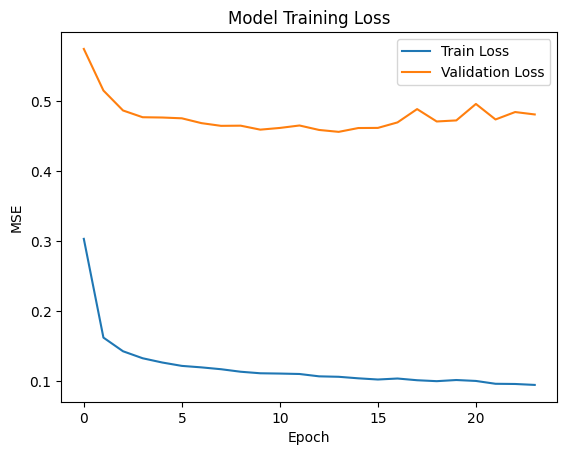

In [12]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

In [13]:
spec_reconstruction = model.predict(data_nopad, verbose=0)

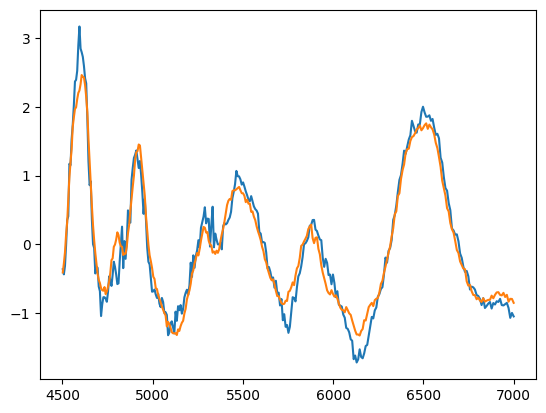

In [14]:
i = 2000
plt.plot(wvl_nopad, data_nopad[i])
plt.plot(wvl_nopad, spec_reconstruction[i])
plt.show()

In [15]:
encoder = keras.Model(model.input, model.get_layer("LS").output)
encoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 327)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       167,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LS (Dense)                      │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 237,827 (929.01 KB)

 Trainable params: 237,827 (929.01 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
encoded_spectra = encoder.predict(data_nopad, verbose=0)
encoded_spectra.shape

(4013, 3)

In [17]:
df_metadata = df_metadata.reset_index()
encodings_df = pd.DataFrame(encoded_spectra, index=df_metadata.index, columns=["latent_0","latent_1", "latent_2"])
encodings_df=encodings_df.join(df_metadata)

In [18]:
import plotly.express as px
import plotly

fig = px.scatter_3d(
    encodings_df,
    x='latent_0',
    y='latent_1',
    z='latent_2',
    color='SN Maintype',
    hover_name='SN Subtype',
    hover_data=["SN Name", "SN Maintype", "SN Maintype ID", "SN Subtype", "SN Subtype ID", "Spectral Phase"],
)


plotly.offline.plot(fig, filename='maintype.html')

fig.show()

In [23]:
import plotly.express as px
import plotly

fig = px.scatter_3d(
    encodings_df[encodings_df["SN Subtype"] == "Ia-norm"],
    x='latent_0',
    y='latent_1',
    z='latent_2',
    color='Spectral Phase',
    hover_name='SN Name',
    hover_data=["SN Name", "SN Maintype", "SN Maintype ID", "SN Subtype", "SN Subtype ID", "Spectral Phase"],
    color_continuous_scale="rdbu",
    range_color=[-14,14]
)


plotly.offline.plot(fig, filename='spectralphase.html')

fig.show()

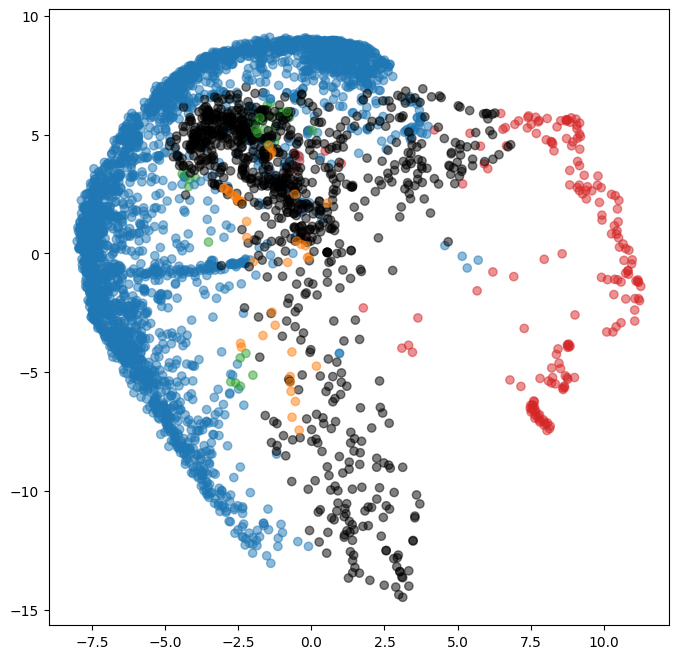

In [ ]:
c = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "k"
]

colors_dict = {
    "Ia-norm": c[0],
    "Ia-91T": c[0],
    "Ia-91bg": c[0],
    "Iax": c[0],
    "Ia-csm": c[0],
    "Ia-pec": c[0],

    "Ib-norm": c[-1],
    "IIb": c[-1],
    "Ibn": c[1],
    "Ib-pec": c[1],

    "Ic-norm": c[-1],
    "Ic-broad": c[-1],
    "Ic-pec": c[2],

    "IIP": c[3],
    "IIL": c[3],
    "II-pec": c[3],
    "IIn": c[3],
    }

colors = df_metadata["SN Subtype"].map(colors_dict).values

fig, ax = plt.subplots(figsize=(8, 8))
# ax = fig.add_subplot(projection='3d')

ax.scatter(
    encoded_spectra[:, 0],
    encoded_spectra[:, 1],
    # encoded_spectra[:, 2],
    alpha=0.5,
    c=colors,
    )
fig.show()

In [ ]:
decoder = keras.Model(model.get_layer("afterLS").input, model.output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


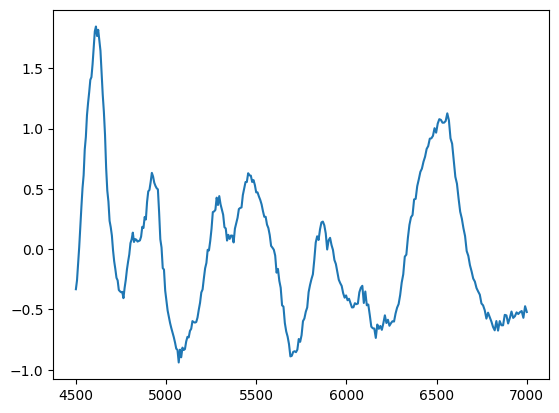

In [ ]:
test_Ia_LS = np.array([0, 5])[np.newaxis]
test_Ia = decoder.predict(test_Ia_LS)[0]
plt.plot(wvl_nopad, test_Ia)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


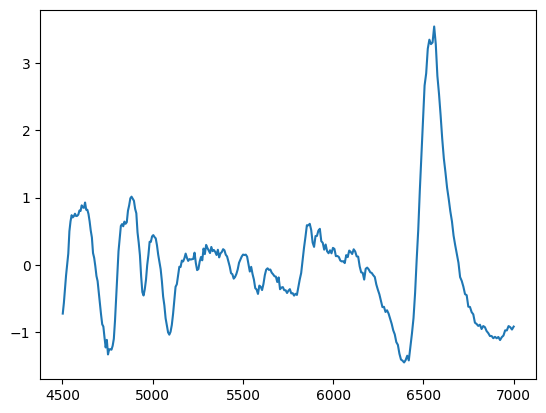

In [ ]:
test_Ia_LS = np.array([10, 0])[np.newaxis]
test_Ia = decoder.predict(test_Ia_LS)[0]
plt.plot(wvl_nopad, test_Ia)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


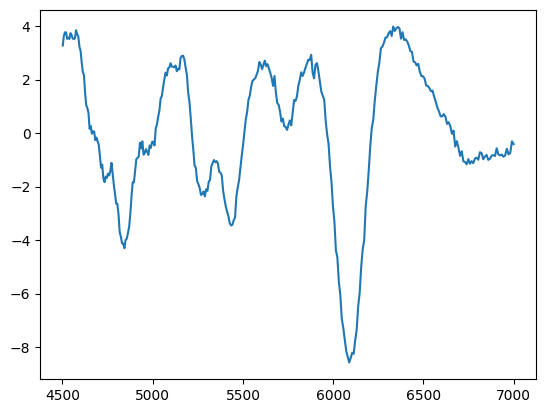

In [ ]:
test_Ia_LS = np.array([-15, -15])[np.newaxis]
test_Ia = decoder.predict(test_Ia_LS)[0]
plt.plot(wvl_nopad, test_Ia)